In [78]:
from pathlib import Path
import datetime
import sys
import scipy.integrate
import scipy.signal
import random
import math
from scipy.fft import fft, ifft

%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

import matplotlib as mpl
import matplotlib.font_manager as fm
from pathlib import Path
plt.rcParams['font.family'] = 'sans-serif'
def get_super(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)
def get_sub(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)


In [31]:
# Load data from fit values
csv_filename = '240916_g2p6_Pd_26_2000sccm_average_dataBest_Fitpeak' #this is the only line that needs to be modified
df_data = pd.read_csv(csv_filename+".csv",index_col=[0,1])


In [20]:
# Load data from fit values
csv_filename = '240911_CuAl2O3_100ppm_JDN2_28_CO_550_600_124mW_200s_2ndBest_Fit2000_2200v2' #this is the only line that needs to be modified
df_data = pd.read_csv(csv_filename+".csv",index_col=[0,1])
print(df_data)

                                     0                      1  \
2.5   names                       lz1_                   lz2_   
      locations     2094.5738001863874        2112.3799612043   
      FWHM          19.535202590698113     16.634242921513472   
      areas       -0.03026335299017235  -0.024702428951121097   
7.5   names                       lz1_                   lz2_   
...                                ...                    ...   
192.5 areas       -0.02485794925309654  -0.019117365040052157   
197.5 names                       lz1_                   lz2_   
      locations      2094.731096737126      2112.463198827694   
      FWHM          19.684513917632607      16.44844059798506   
      areas      -0.028655437016456814  -0.022601259457236365   

                                     2  
2.5   names                       lz3_  
      locations     2125.0000001365124  
      FWHM           20.66925188806698  
      areas       -0.02035618910087542  
7.5   names   

In [21]:
#Collating Areas
dft_areas = df_data.loc[pd.IndexSlice[:,"areas"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_areas = dft_areas.set_index(dft_areas.index.get_level_values(0))
#dft_locations
dft_locations = df_data.loc[pd.IndexSlice[:,"locations"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_locations = dft_locations.set_index(dft_locations.index.get_level_values(0))
#dft_FWHM
dft_FWHM = df_data.loc[pd.IndexSlice[:,"FWHM"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_FWHM = dft_FWHM.set_index(dft_FWHM.index.get_level_values(0))


print(df_data)
print(df_data.loc[pd.IndexSlice[:,"locations"],:])

                                     0                      1  \
2.5   names                       lz1_                   lz2_   
      locations     2094.5738001863874        2112.3799612043   
      FWHM          19.535202590698113     16.634242921513472   
      areas       -0.03026335299017235  -0.024702428951121097   
7.5   names                       lz1_                   lz2_   
...                                ...                    ...   
192.5 areas       -0.02485794925309654  -0.019117365040052157   
197.5 names                       lz1_                   lz2_   
      locations      2094.731096737126      2112.463198827694   
      FWHM          19.684513917632607      16.44844059798506   
      areas      -0.028655437016456814  -0.022601259457236365   

                                     2  
2.5   names                       lz3_  
      locations     2125.0000001365124  
      FWHM           20.66925188806698  
      areas       -0.02035618910087542  
7.5   names   

In [22]:
#Making new array
cond = "550-6002nd"
dft_areas = pd.concat([dft_areas], keys=[cond])
dft_locations = pd.concat([dft_locations], keys=[cond])
dft_FWHM = pd.concat([dft_FWHM], keys=[cond])
print(dft_areas)
#Adding on the next ones
try:
    df_areas
except NameError:
    df_areas =dft_areas
    df_locations =dft_locations
    df_FWHM =dft_FWHM
else:
    df_areas =pd.concat([df_areas, dft_areas]).astype(float)
    df_locations =pd.concat([df_locations, dft_locations])
    df_FWHM =pd.concat([df_FWHM, dft_FWHM])
    
df_locations = df_locations.sort_index().astype(float)
df_areas = df_areas.sort_index().astype(float)
df_FWHM = df_FWHM.sort_index().astype(float)
print(df_areas)

                                    lz1_                    lz2_  \
550-6002nd 2.5      -0.03026335299017235   -0.024702428951121097   
           7.5     -0.029550453819465174   -0.024239066711028066   
           12.5    -0.027833217723827047   -0.022539330193437096   
           17.5    -0.025508719486355726   -0.020855588271609785   
           22.5    -0.023211344338011794   -0.018971095183680377   
           27.5    -0.020611732699175742   -0.016941382268750728   
           32.5    -0.018007153299139867   -0.014835346513350117   
           37.5    -0.014871405637114551   -0.012662803190328094   
           42.5    -0.011682232541763234   -0.009981253557801975   
           47.5    -0.009001646647452028  -0.0068736782378741035   
           52.5    -0.005478035521666478   -0.003695577933603984   
           57.5   -0.0020687951950398385  -0.0009518476948921447   
           62.5    0.0014356327582533157    0.001649633410247174   
           67.5      0.00502748959465202    0.00

In [93]:
peak = "lz3_"
#df_FWHM = df_FWHM.astype(float)
for space in df_areas.index.get_level_values(0).unique():
    mean_FW = np.mean(df_FWHM.loc[pd.IndexSlice[space,2.5:97.5],peak].to_numpy())
    mean_FW2 = np.mean(df_FWHM.loc[pd.IndexSlice[space,102.5:197.5],peak].to_numpy())
    print(space + ": "+str(mean_FW) + ":"+str(mean_FW2))

#print(df_FWHMtest.loc[(space,slice(2.5,7.5)),peak].to_numpy())

650-700: 22.194756192093987:22.179082777947475
600-650: 21.66659491262662:21.576037832209813
550-600: 19.32403566589702:19.22618935919305
500-550: 20.307299070463536:19.90889676462435
450-500: 18.834785846492174:19.07300054224275
400-450: 17.5140037157301:17.404353782336468


                   lz1_      lz2_      lz3_
400-450 2.5   -0.011481 -0.008485 -0.007021
        7.5   -0.011562 -0.008252 -0.006382
        12.5  -0.011491 -0.007608 -0.005869
        17.5  -0.011057 -0.006835 -0.005167
        22.5  -0.010465 -0.006060 -0.004479
...                 ...       ...       ...
450-500 177.5 -0.005588 -0.004566 -0.004826
        182.5 -0.007675 -0.005958 -0.005741
        187.5 -0.009605 -0.007494 -0.006791
        192.5 -0.012343 -0.008552 -0.007730
        197.5 -0.015362 -0.009336 -0.008684

[80 rows x 3 columns]


In [101]:
peak = "lz2_"
#df_FWHM = df_FWHM.astype(float)
df_locations = df_locations.sort_index().astype(float)
for space in df_areas.index.get_level_values(0).unique():
    mean_loc = np.mean(df_locations.loc[pd.IndexSlice[space,2.5:97.5],peak].to_numpy())
    mean_loc2 = np.mean(df_locations.loc[pd.IndexSlice[space,102.5:197.5],peak].to_numpy())
    print(space + ": "+str(mean_loc) + ":"+str(mean_loc2))

#print(df_FWHMtest.loc[(space,slice(2.5,7.5)),peak].to_numpy())

650-700: 2112.1282610077496:2112.127042917962
600-650: 2111.563076053397:2111.493117162785
550-600: 2113.3383444570204:2113.090032072251
500-550: 2112.484432574862:2112.467934523308
450-500: 2113.094304675366:2113.0725765244947
400-450: 2113.224513351894:2112.9639473863526


In [25]:
#normalizing areas
df_areas

lz1_      lz2_      lz3_
400-450 2.5   -0.011481 -0.008485 -0.007021
        7.5   -0.011562 -0.008252 -0.006382
        12.5  -0.011491 -0.007608 -0.005869
        17.5  -0.011057 -0.006835 -0.005167
        22.5  -0.010465 -0.006060 -0.004479
...                 ...       ...       ...
650-700 177.5 -0.013600 -0.010158 -0.013283
        182.5 -0.018084 -0.012875 -0.015732
        187.5 -0.022336 -0.015871 -0.017917
        192.5 -0.027120 -0.018787 -0.020172
        197.5 -0.031119 -0.022588 -0.022309

[280 rows x 3 columns]

{'lz1_': -0.0011095496449487312, 'lz2_': 0.0004692454215200013, 'lz3_': -0.00015592749620921506}
        400-450    450-500    500-550    550-600  550-6002nd    600-650  \
lz1_  15.254850  15.997438  17.982300  21.619010   21.619010  21.696190   
lz2_   5.240331   6.202851   7.839775   9.358560    9.358560  10.766893   
lz3_   8.596925   8.670295  11.370175  14.218084   14.218084  14.564122   

        650-700  
lz1_  22.067280  
lz2_  10.012596  
lz3_  15.595112  


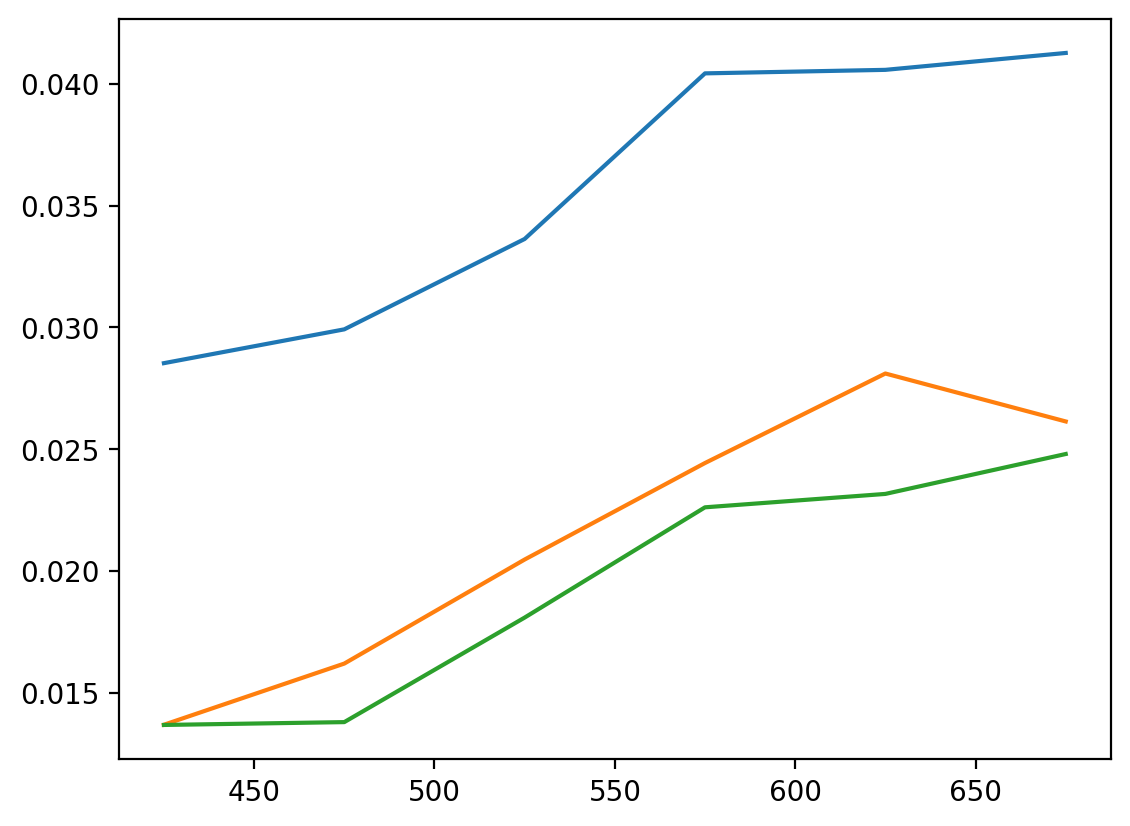

In [26]:
#Getting Area Maximums and Shifts
df_adj_areas =df_areas.copy()
area_shift = {}
area_int= {}
area_per = {}
rate_of_red = {}
kernel_size = 3
kernel = np.ones(kernel_size) / kernel_size
powers = {"400-450":1.746,"450-500":1.46,"500-550":1.06,"550-600":1.024,"600-650":1.069,"650-700":1.0164,"550-6002nd":1}
order = {"400-450":3,"450-500":1,"500-550":4,"550-600":0,"600-650":5,"650-700":2,"550-6002nd":6}
ss_per= {"lz1_":0.313,"lz2_":0.430,"lz3_":0.285}
ss_area= {"lz1_":0.187,"lz2_":0.261,"lz3_":0.159}
for peak in df_areas.columns:
    rate_of_red[peak] = (powers["550-6002nd"]*2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice["550-6002nd",:],peak].to_numpy()))-powers["550-600"]*2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice["550-600",:],peak].to_numpy())))/6
print(rate_of_red)
#area_int[space][peak] = powers[i]*2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
for space in df_areas.index.get_level_values(0).unique():
    area_shift[space] = {}
    area_int[space] = {}
    area_per[space] = {}
    space_total = 0
    for peak in df_areas.columns:
        shift_loc = np.argmax(np.convolve(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy(),kernel, mode='same'))
        #shift_loc = np.argmin(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy())
        area_shift[space][peak] = df_areas.index.get_level_values(1)[shift_loc]
        #area_int[space][peak] = np.convolve(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy(),kernel, mode='same')[shift_loc]
        area_int[space][peak] = powers[space]*2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
        area_int[space][peak] = area_int[space][peak]-rate_of_red[peak]*order[space]
        df_adj_areas.loc[pd.IndexSlice[space,:],peak] = powers[space]*df_areas.loc[pd.IndexSlice[space,:],peak]-rate_of_red[peak]*order[space]
    for peak in df_areas.columns:
        space_total += area_int[space][peak]
    for peak in df_areas.columns:
        area_per[space][peak] = 100*(area_int[space][peak]/ss_area[peak])
    #temp_shift = df_areas.loc[pd.IndexSlice[space,:],peak]
    
    #append([df_areas.loc[pd.IndexSlice[space,:],peak].reset_index( level = [0] ).drop(columns='level_0') ,space])
df_area_shift = pd.DataFrame.from_dict(area_shift)
df_area_int = pd.DataFrame.from_dict(area_int)
df_area_per = pd.DataFrame.from_dict(area_per)
wl_dep_index = [[425,425,425],[475,475,475,],[525,525,525],[575,575,575],[625,625,625],[675,675,675]]
df_area_int = df_area_int.rename(columns =  {"400-450":425,"450-500":475,"500-550":525,"550-600":575,"600-650":625,"650-700":675,"550-6002nd":575})

plt.plot(df_area_int.transpose())
print(df_area_per)
#plt.plot(df_area_per.transpose())

In [109]:
#reconstruction of areas into timespace
df_grad_areas =df_adj_areas.copy()
kernel_size = 1
kernel = np.ones(kernel_size) / kernel_size
for space in df_adj_areas.index.get_level_values(0).unique()[:]:
    for peak in df_adj_areas.columns:
        np_temp = df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()
        np_temp =np.gradient(np_temp,5,edge_order=1)*df_adj_areas.index.get_level_values(1).unique()[-1]/4
        
        np_temp = np.concatenate([np.convolve(np_temp[:20], kernel, mode='same'),np.convolve(np_temp[20:], kernel, mode='same')])
        
        
        
        df_grad_areas.loc[pd.IndexSlice[space,:],peak] = np_temp

print(df_grad_areas)

                   lz1_      lz2_      lz3_
400-450 2.5   -0.000804  0.002304  0.006310
        7.5   -0.000049  0.004330  0.005687
        12.5   0.002494  0.006999  0.005999
        17.5   0.005066  0.007644  0.006864
        22.5   0.006434  0.010464  0.008387
...                 ...       ...       ...
650-700 177.5 -0.046695 -0.025978 -0.024996
        182.5 -0.043135 -0.028207 -0.022880
        187.5 -0.044615 -0.029192 -0.021926
        192.5 -0.043366 -0.033167 -0.021685
        197.5 -0.039485 -0.037537 -0.021097

[280 rows x 3 columns]


<class 'pandas.core.frame.DataFrame'>
[-0.05, -0.038, -0.025, -0.012, 0.0, 0.012, 0.025, 0.038, 0.05]


<Figure size 640x480 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

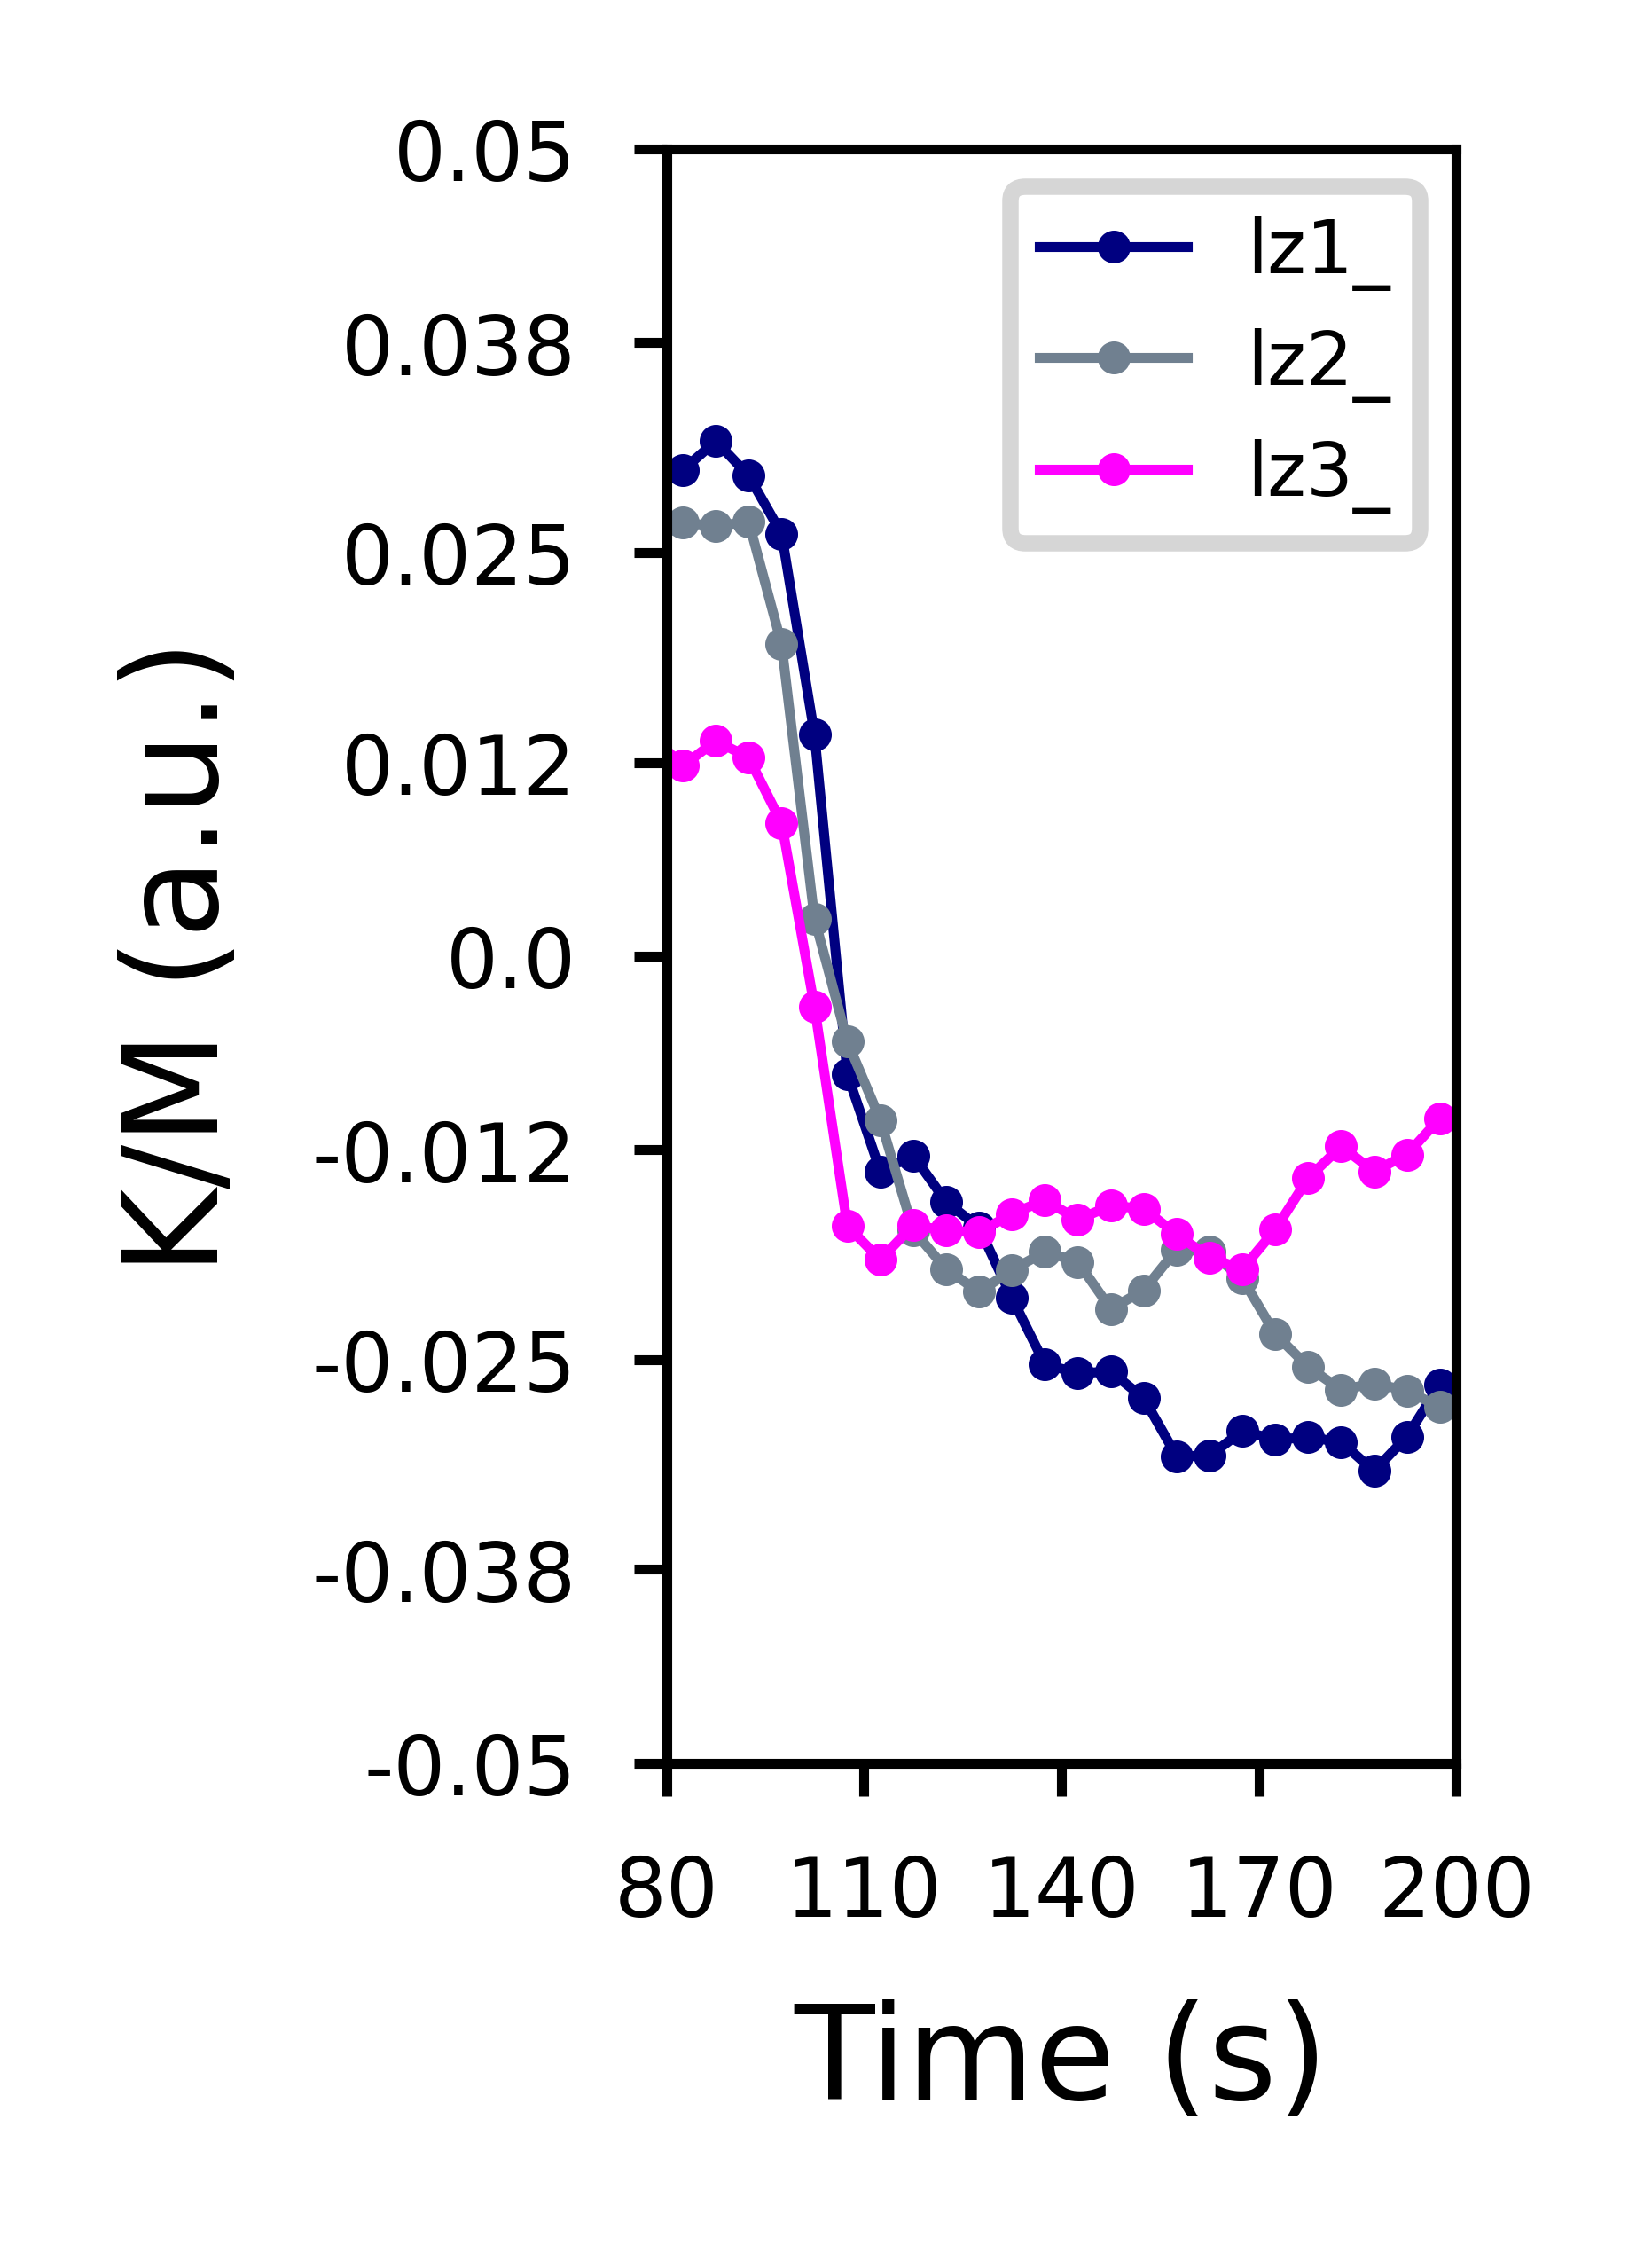

In [119]:

#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_200sAreas_2000_2200_500_550_areas'

plt.figure( linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(1.5, 2), linewidth = 0.6*font_size)

#ax.plot(area_plot[0][0].index.to_list(), area_plot[0][0].iloc[:,0].values, label=area_plot[0][1])
#peak= "lz3_"
#for space in df_areas.index.get_level_values(0).unique():
    #ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)
print(type(df_area_int))
#ax.plot(df_area_int.transpose(),label=df_area_int.transpose().columns,linewidth = 0.6*font_size,linestyle="none",marker=".",markersize=1*font_size)
colors=["navy","slategray","magenta"]
i=0
space = "500-550"
#for peak in df_area_int.transpose().columns:
    #ax.errorbar(df_area_int.transpose()[peak].index.to_numpy(),df_area_int.transpose()[peak].values,color = colors[i],label = peak,xerr=25,linewidth = 0.6*font_size,linestyle="none",marker=".",markersize=2*font_size,capsize= 1*font_size,elinewidth=0.4*font_size,capthick=0.4*font_size)
    #i+=1
#for space in df_areas.index.get_level_values(0).unique():
 #   ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)
for peak in df_grad_areas.columns:   
    ax.plot(df_grad_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_grad_areas.loc[pd.IndexSlice[space,:],peak],label=peak,color=colors[i],linewidth = 0.6*font_size,linestyle="-",marker=".",markersize=2*font_size)
    i+=1
#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis



#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Time (s)", fontsize = 8*font_size)
ax.set_ylabel("K/M (a.u.)", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=6*font_size)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 200 #High Range
xlow = 80 #Low Range
xpoints = 5 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xlow, xhigh)

#manual xlabels
#xlabels=[400,450,500,550,600,650,700]
#ax.set_xticks(xlabels)
#ax.set_xticklabels(xlabels)

#Adjusting range and tick frequency of y axis
yhigh = 0.05 #High Range
ylow = -0.05 #Low Range
ypoints = 9 #How many points you want on your axis
ydigits = 3 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]

print (ylabels)
ax.set_yticks(ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 4.5*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

In [3]:
slice_time=102.5
peak_set = []
xdat = df_data.loc[slice_time].loc["xdat",:]
ydat = df_data.loc[slice_time].loc["ydat",:]
best_fit = df_data.loc[slice_time].loc["best fit",:]
bkg = df_data.loc[slice_time].loc["bkg_",:]
for peak in df_data.loc[slice_time].iloc[4:,:].index:
    peak_set.append([peak,df_data.loc[slice_time].loc[peak,:]])


[-0.0003, 8e-05, 0.00047, 0.00085, 0.00123, 0.00162, 0.002]
[-0.03, 0.008, 0.047, 0.085, 0.123, 0.162, 0.2]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

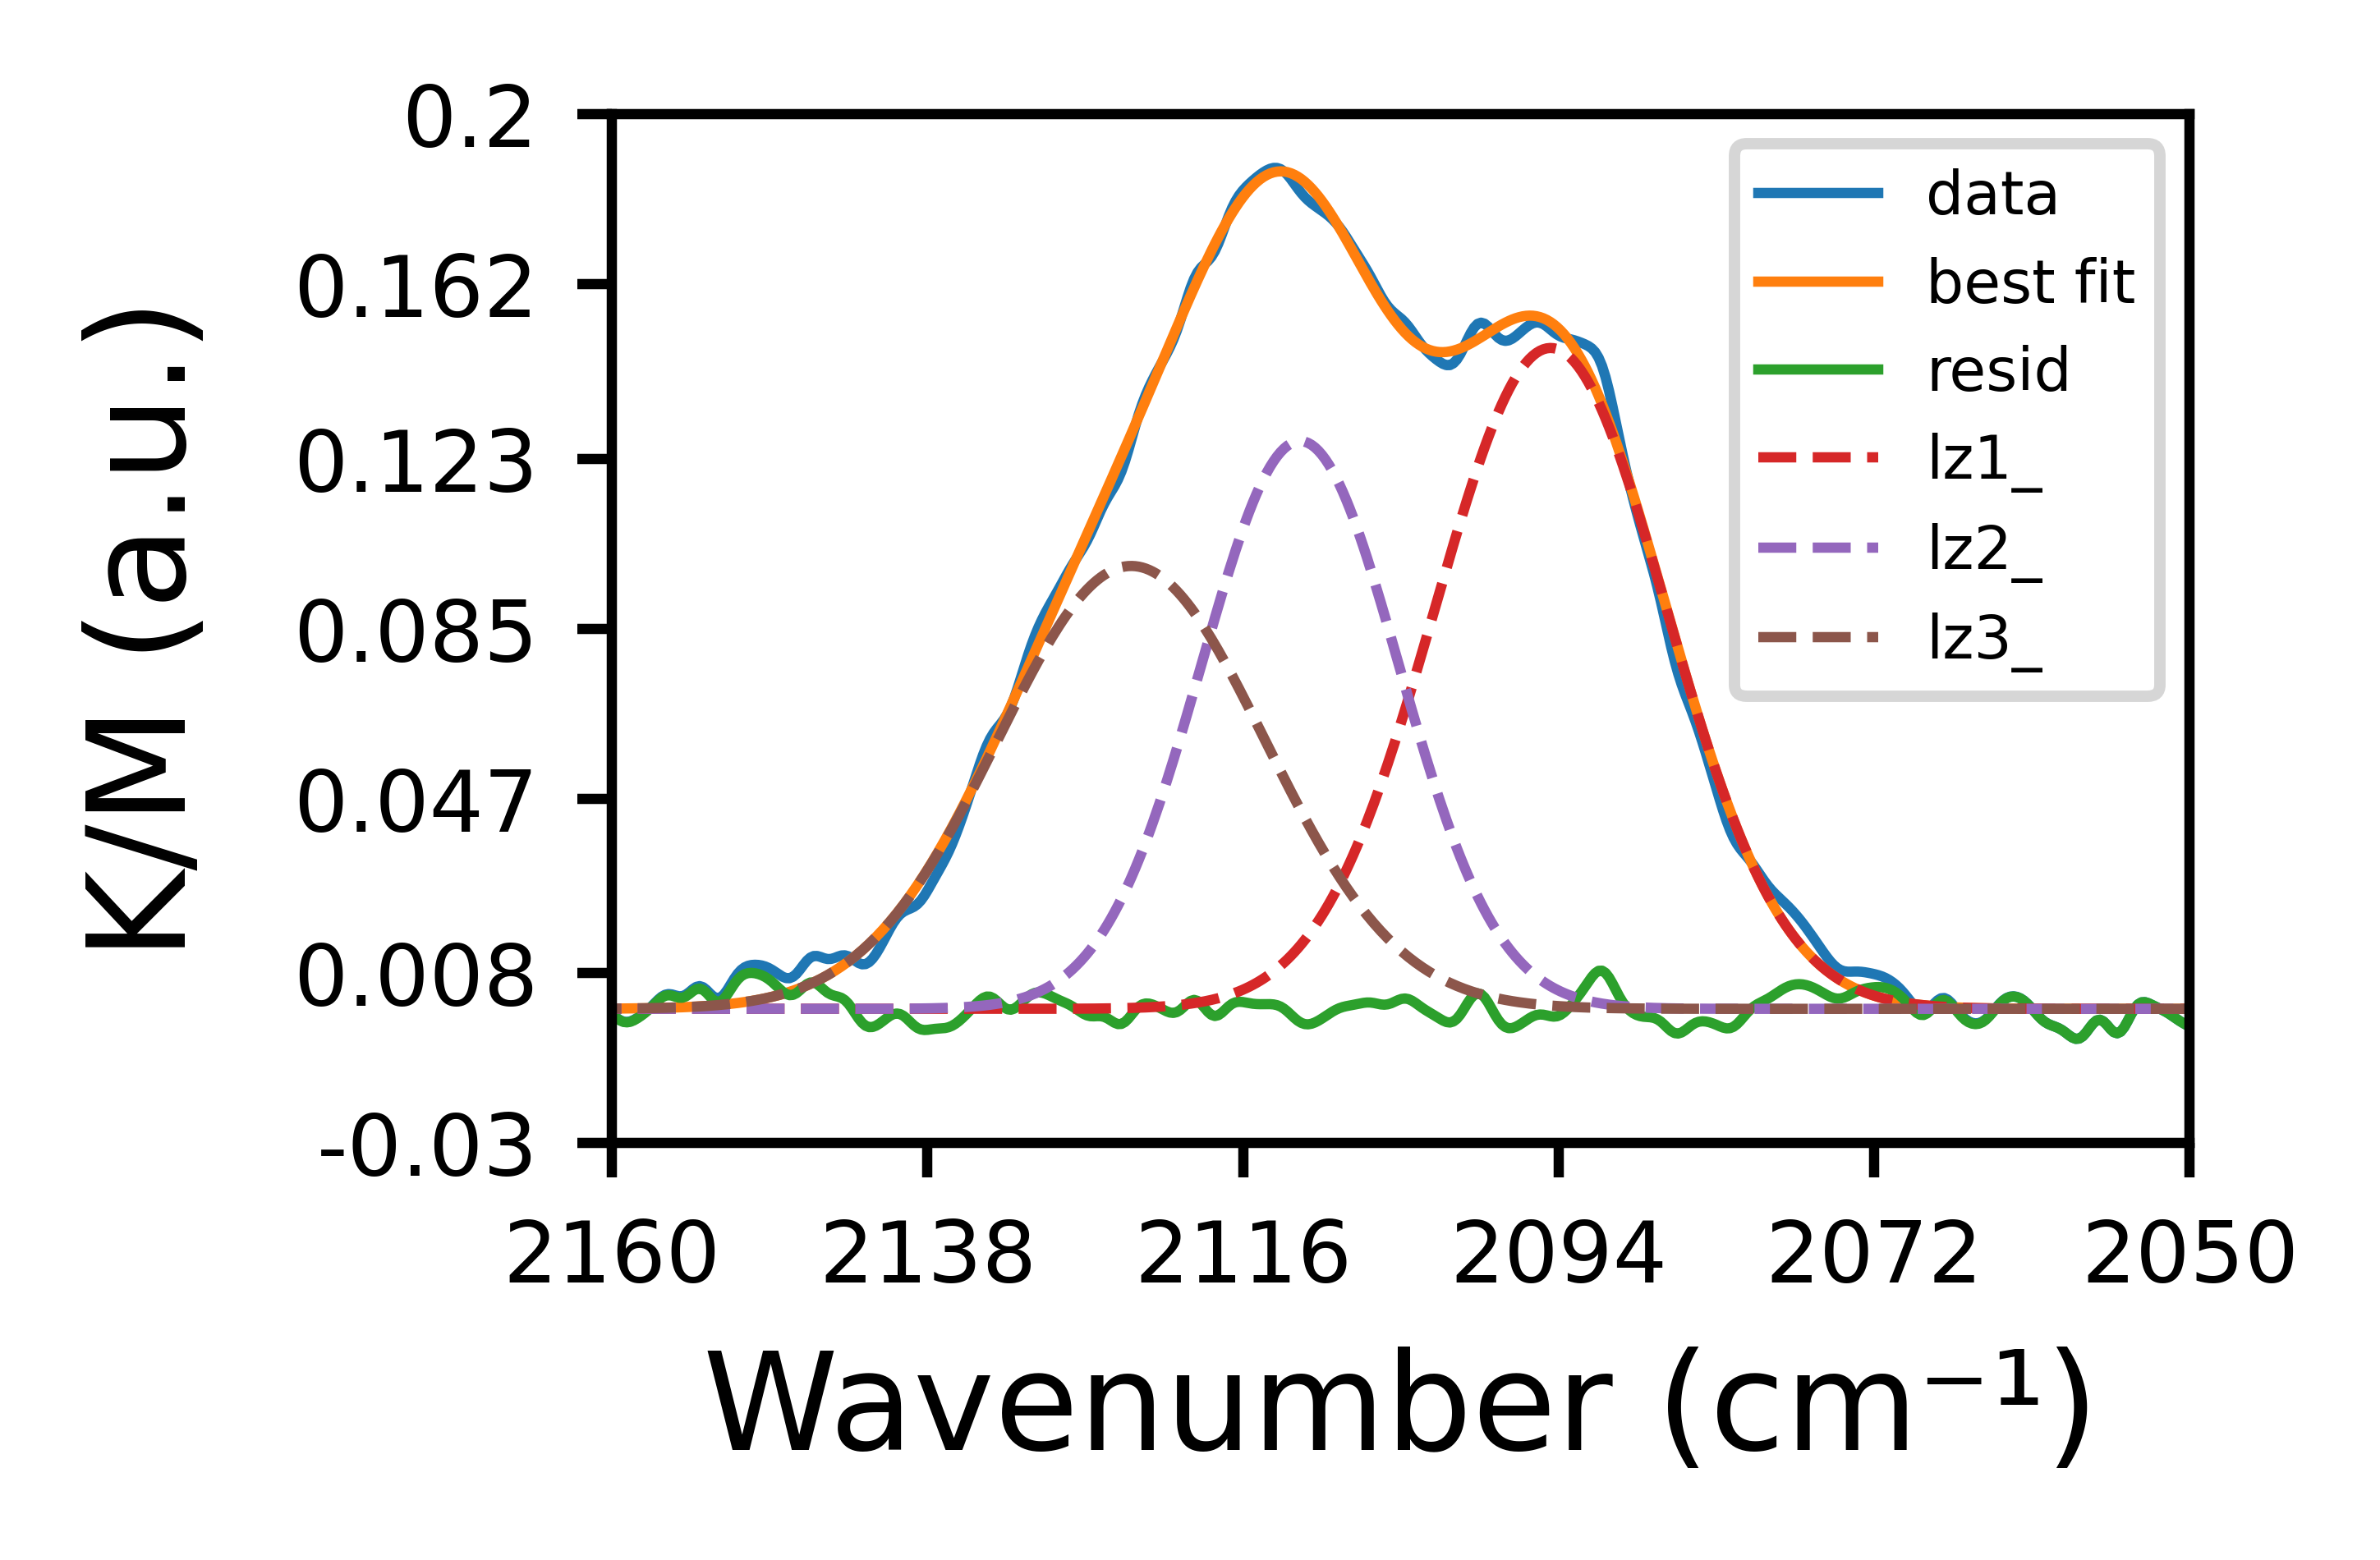

In [19]:
#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_600_650_116mW_200sBest_Fit_Values2000_2200_102.5s'

plt.figure(linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(3, 2), linewidth = 0.6*font_size)
ax.plot(xdat, ydat-bkg, label='data',linewidth = 0.6*font_size)
ax.plot(xdat, best_fit-bkg, label='best fit',linewidth = 0.6*font_size)
ax.plot(xdat, ydat-best_fit, label='resid',linewidth = 0.6*font_size)

for name, comp in peak_set:
    ax.plot(xdat, comp, '--', label=name,linewidth = 0.6*font_size)


#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
ax.set_ylabel("K/M (a.u.)", fontsize = 8*font_size,labelpad=6.9)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2160 #High Range
xlow = 2050 #Low Range
xpoints = 6 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.002 #High Range
ylow = -0.0003 #Low Range
ypoints = 7 #How many points you want on your axis
ydigits = 5 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)

ax.set_yticks(ylabels)
for n,y in enumerate(ylabels):
    #ylabels[n] = format(y,'e').replace("0000","")
    ylabels[n] = round(y*100,ydigits)
print (ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3.5*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

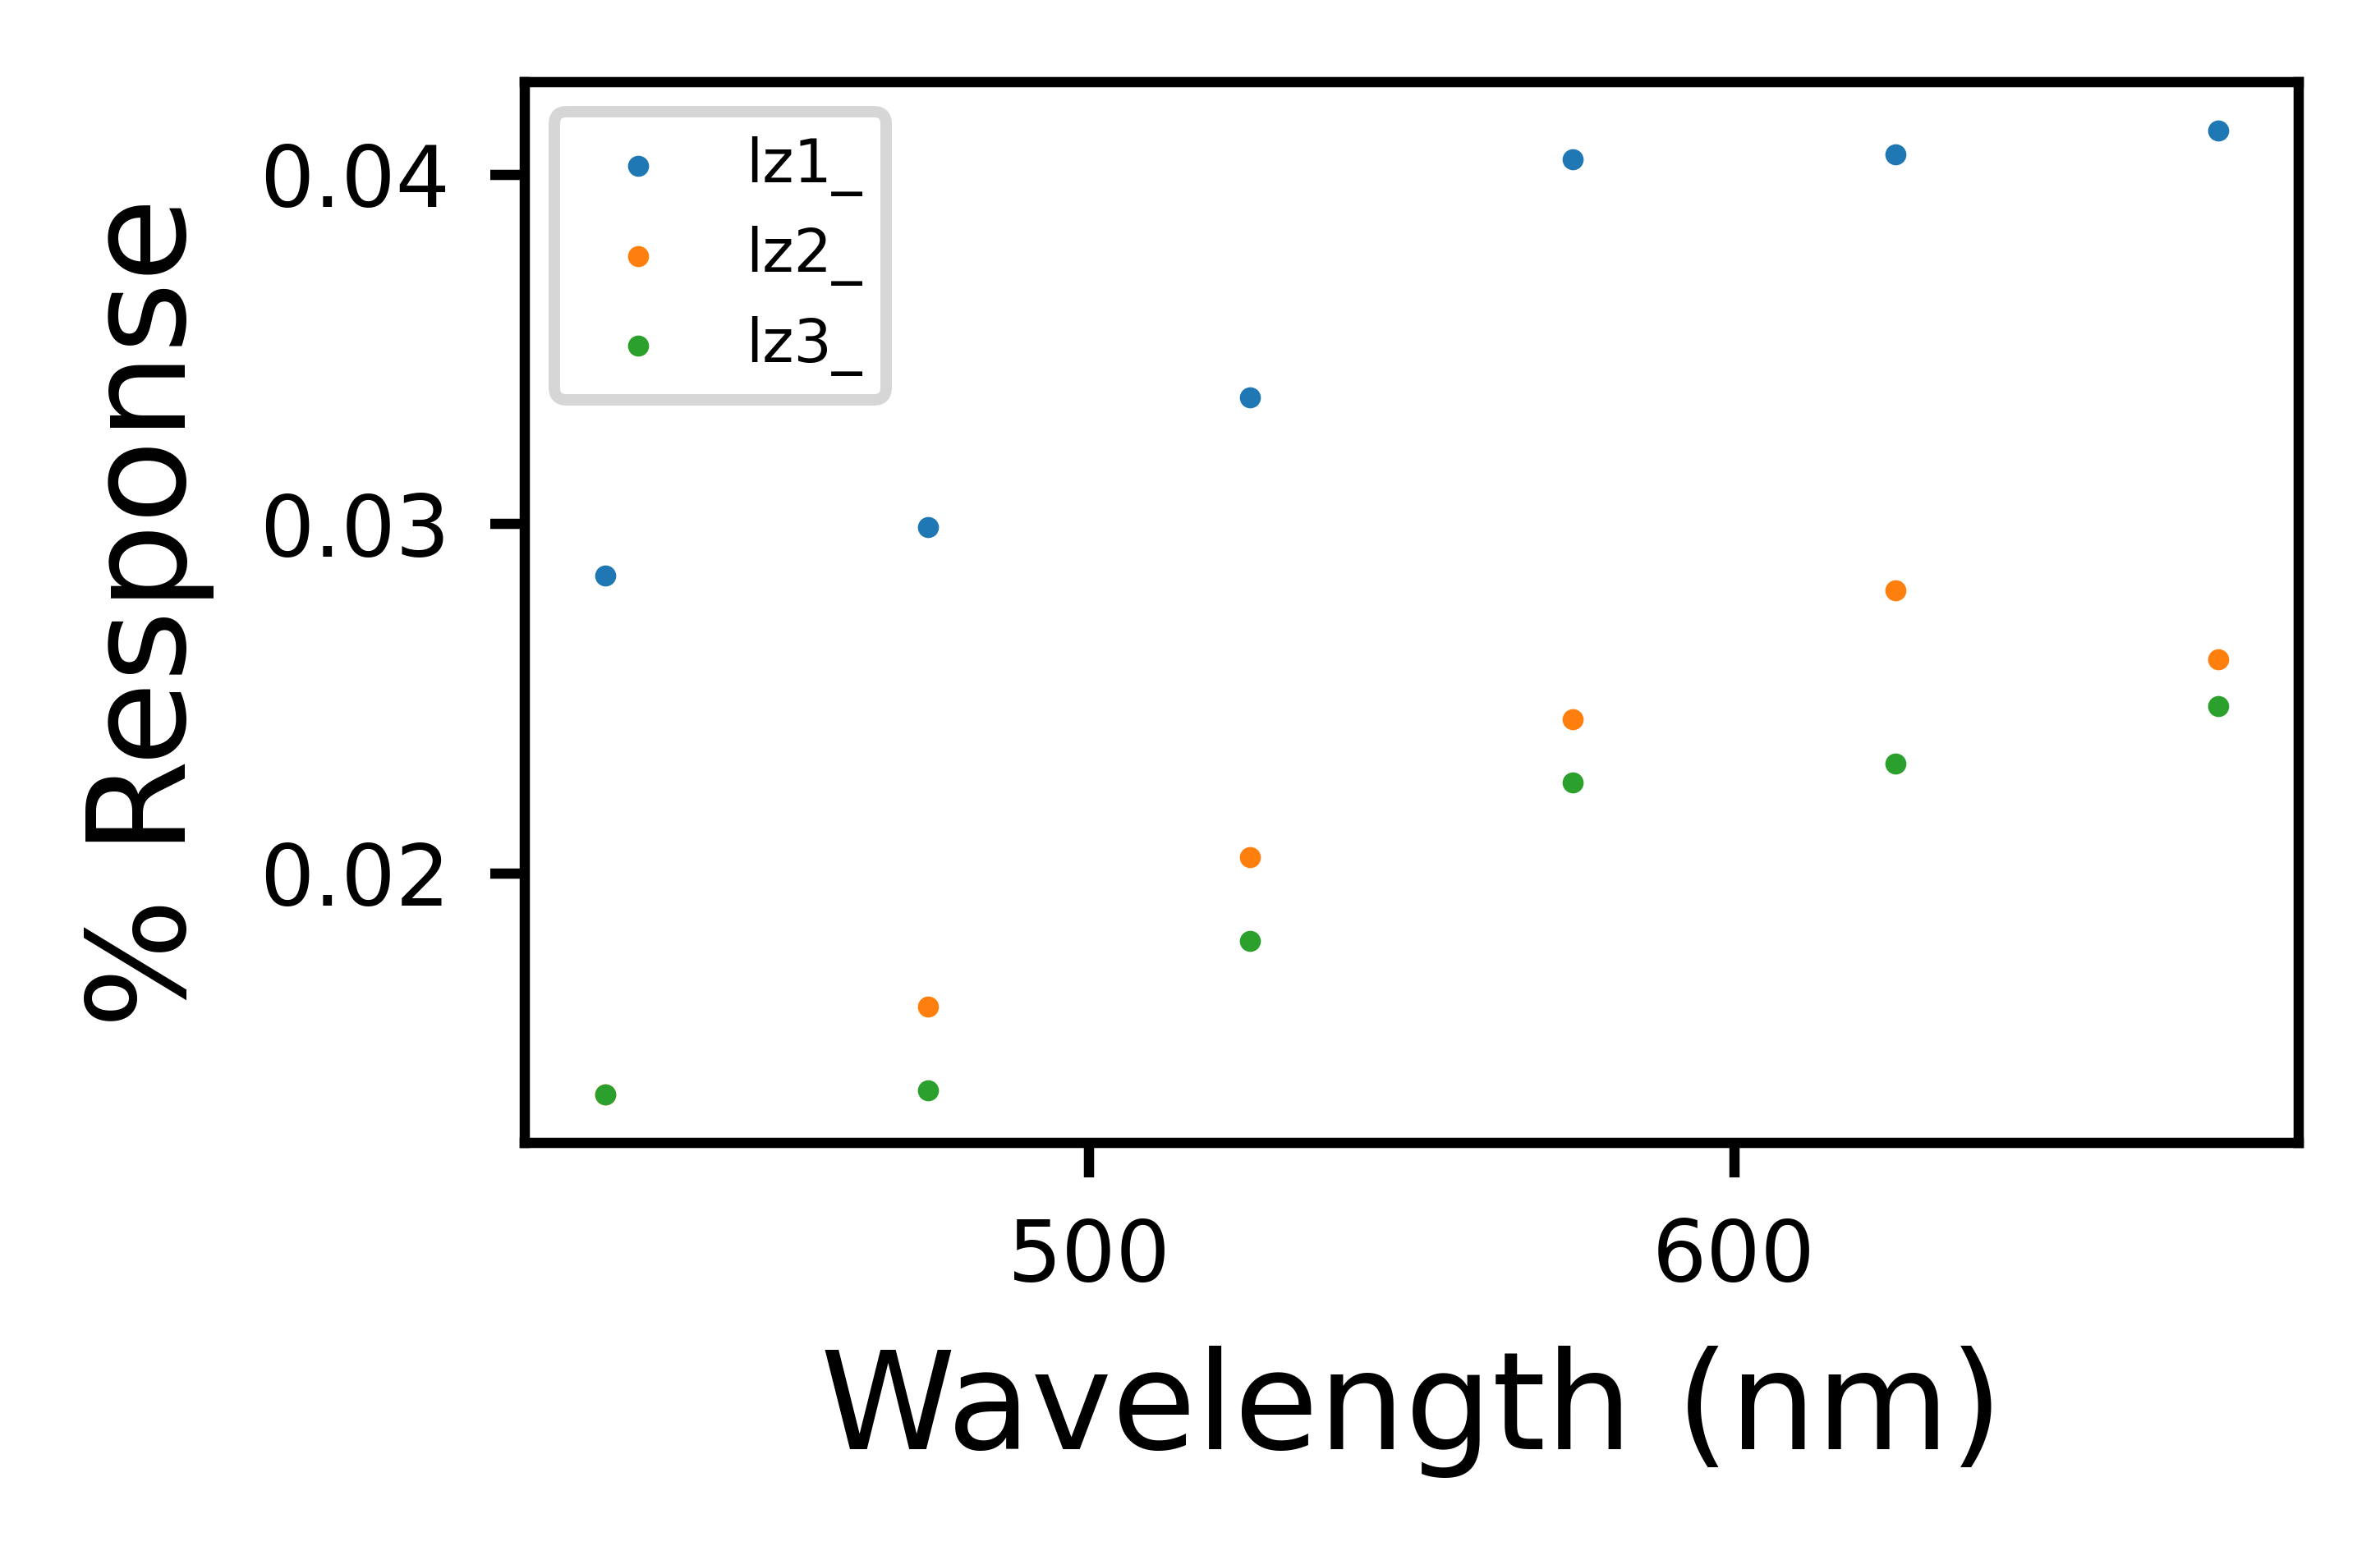

In [142]:

#The plotting proper fig Scatter
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_200sAreas_2000_2200_wavelengthdep'

plt.figure( linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(3, 2), linewidth = 0.6*font_size)

#ax.plot(area_plot[0][0].index.to_list(), area_plot[0][0].iloc[:,0].values, label=area_plot[0][1])
#peak= "lz3_"
#for space in df_areas.index.get_level_values(0).unique():
    #ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)
for peak in df_area_per.transpose().columns.to_list():
    ax.scatter(df_area_int.transpose().index,df_area_int.transpose()[peak],label=peak,s= 0.6*font_size,linewidth = 0.6*font_size)
peak= "550-600"
#for space in df_areas.index.get_level_values(0).unique():
 #   ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)
#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis



#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavelength (nm)", fontsize = 8*font_size)
ax.set_ylabel("% Response", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
#xhigh = 200 #High Range
#xlow = 0 #Low Range
#xpoints = 8 # How many points you want on your axis
#xdigits = 0 # Percision of tick points, will round to how many digits you enter here

#xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
#if xdigits <= 0:
#    xlabels = [int(num) for num in xlabels]
#ax.set_xticks(xlabels)
#ax.set_xticklabels(xlabels)
#ax.set_xlim(xlow, xhigh)

#Adjusting range and tick frequency of y axis
#yhigh = 0.045 #High Range
#ylow = 0.01 #Low Range
#ypoints = 6 #How many points you want on your axis
#ydigits = 0 # Percision of tick points, will round to how many digits you enter here

#ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
#if ydigits <= 0:
    #ylabels = [int(num) for num in ylabels]

#print (ylabels)
#ax.set_yticks(ylabels)
#ax.set_yticklabels(ylabels)
#ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3.5*font_size, loc = "upper left", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()